# EEG_06 — Braindecode Baseline Subject-Specific (Leave-One-Session-Out)

Questo notebook testa **6 modelli end-to-end** di [Braindecode](https://braindecode.org) sul segnale EEG grezzo,
usando il clustering semantico a 4 e 5 classi in modalità **subject-specific**.

**Differenza con EEG_05**: qui ogni modello viene addestrato su un singolo soggetto (leave-one-session-out).
Questo esperimento risponde alla domanda: **il segnale EEG contiene struttura decodificabile?**
Se anche subject-specific è a chance → il segnale non è sufficiente.
Se supera il chance level → il problema del SI era solo il domain shift inter-soggetto.

**Richiede**: ambiente `daniele_311` (Python 3.11) per Labram.

## Modelli testati
| Modello | Architettura | Parametri | Note |
|---------|-------------|-----------|------|
| **EEGNet** | CNN compatta | ~2.8K | Baseline leggero, universale |
| **ShallowFBCSPNet** | CNN freq-domain | ~98K | Ispira a FBCSP classico |
| **Deep4Net** | CNN profonda | ~261K | Baseline convoluzionale solido |
| **EEGConformer** | CNN + Transformer | ~429K | Pattern locali e globali |
| **ATCNet** | Attention + TCN | ~44K | Sliding window con attenzione |
| **Labram** | Criss-Cross Transformer | ~5M | Foundation model per EEG, richiede Python 3.11 |

## Setup dati
- Input: segnale EEG grezzo `(batch, 59, 384)` — 59 canali × 384 campioni a 256 Hz (~1.5s)
- Labram: input paddato a `(batch, 59, 400)` per compatibilità con `patch_size=200`
- Label: cluster semantici a **4 classi** (azioni, cognitivo, emozioni, oggetti) o **5 classi**
- Valutazione: **subject-specific** — leave-one-session-out (train: sessioni 1-3, val: sessione 4, test: sessione 5)

Data: 2026-03-24

In [ ]:
# ═══════════════════════════════════════════════════════════
#  TOGGLE CLASSI TARGET — modifica qui per cambiare schema
# ═══════════════════════════════════════════════════════════
USE_CLUSTERS      = True          # False → 110 parole originali
CLUSTER_SCHEME    = "concr4"      # "concr4" | "phon4" | "sem5" | "pos4" | "ward5" | "ward4" | "ward6"
#                                   Schemi EEG-based (ARI≈0, solo analisi):
#                                   "eeg_4" | "eeg_5" | "eeg_z4" | "eeg_z5"
USE_INSTANCE_NORM = True          # Bomatter et al. 2024: normalizza ogni trial indipendentemente
#                                   Rimuove bias per-soggetto senza usare statistiche del train set

# ── Configurazione soggetti e sessioni ──────────────────────
N_SUBJECTS_TEST = None  # None → tutti i 70 soggetti | int → primi N soggetti (per test veloce)
SESSION_TEST    = 5    # sessione usata come test set (1-5)
SESSIONS_TRAIN  = [1, 2, 3, 4]  # sessioni usate come train+val

# ── Sweep config ────────────────────────────────────────────
SWEEP_SCHEMES     = ["concr4", "phon4"]   # schemi da testare nel sweep
SWEEP_MODELS_ONLY = None   # None → tutti i modelli | ["EEGNet"] → solo EEGNet
#                            Esempio baseline veloce: ["EEGNet"]
SWEEP_RESUME      = True   # se True, salta checkpoint già addestrati

# ── Tag per TensorBoard
NORM_TAG = "_norm" if USE_INSTANCE_NORM else ""
# → runs/eeg06_ss_norm/...   oppure   runs/eeg06_ss/...
# ═══════════════════════════════════════════════════════════

In [2]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # fix OpenMP su macOS

import json
import time
import warnings
warnings.filterwarnings('ignore')

from torch.utils.tensorboard import SummaryWriter
import numpy as np
import pandas as pd
import h5py
import torch
from tqdm.auto import tqdm
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
from collections import defaultdict

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

from braindecode.models import EEGNet, EEGConformer, Deep4Net, ShallowFBCSPNet, ATCNet
try:
    from braindecode.models import Labram
    LABRAM_AVAILABLE = True
except ImportError:
    LABRAM_AVAILABLE = False
    print("Labram non disponibile — verrà saltato")

# Device: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("device:", device)
print("Python:", __import__('sys').version.split()[0])
print("torch:", torch.__version__)
import braindecode; print("braindecode:", braindecode.__version__)

device: cuda
Python: 3.11.15
torch: 2.10.0+cu128
braindecode: 1.3.2


In [ ]:
# ============================================================
# CONFIGURAZIONE E PATHS (CSV di Paolo)
# ============================================================
import os, sys, json
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from collections import defaultdict

project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

CSV_ROOT   = project_root / "data" / "raw_csv" / "training_set"
CONFIGS    = project_root / "configs" / "label_schemes"

# Parametri EEG
N_CHANS         = 61
N_TIMES         = 384
N_TIMES_CBRAMOD = 400
SFREQ           = 256

# Training
BATCH_SIZE   = 64
MAX_EPOCHS   = 100
PATIENCE     = 15
LR           = 1e-3
WEIGHT_DECAY = 1e-4

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# Mapping parola → label_id
with open(CONFIGS / "label2idx.json") as f:
    word2labelid = json.load(f)

# Schema cluster (controllato dal TOGGLE in cima al notebook)
_scheme = CLUSTER_SCHEME if USE_CLUSTERS else "raw110"
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(
    _scheme, project_root / "data" / "interim"
)
chance_level = 1.0 / N_CLASSES

print(f"CSV root  : {CSV_ROOT}")
print(f"Schema    : {_scheme} | {N_CLASSES} classi | Chance: {100/N_CLASSES:.1f}%")
print(f"Config OK")

In [ ]:
# ============================================================
# META_DF DA CSV DI PAOLO
# PXXX_SYYY/parola_img.csv → subject_id, session_id (int), label_idx
# ============================================================
from torch.utils.data import Dataset, DataLoader

def parse_folder(folder_name: str):
    """'P003_S002' → (3, 2)"""
    parts = folder_name.split("_")
    return int(parts[0][1:]), int(parts[1][1:])

def load_csv_trial(csv_path: Path) -> np.ndarray:
    return pd.read_csv(csv_path, header=None).values.astype(np.float32)

records = []
for sess_dir in sorted(CSV_ROOT.iterdir()):
    if not sess_dir.is_dir():
        continue
    subj_id, sess_id = parse_folder(sess_dir.name)
    for csv_path in sorted(sess_dir.iterdir()):
        if csv_path.suffix != ".csv":
            continue
        word = csv_path.stem.replace("_img", "")
        if word not in word2labelid:
            continue
        label_id = word2labelid[word]
        if label_id not in labelid2cluster:
            continue
        records.append({
            "path_csv":   str(csv_path),
            "subject_id": str(subj_id).zfill(2),
            "session_id": sess_id,          # int
            "label_idx":  label_id,
        })

meta = pd.DataFrame(records)

# ── Distribuzione sessioni per soggetto ────────────────────────────────────
sess_per_subj = meta.groupby("subject_id")["session_id"].nunique()
print(f"Meta         : {len(meta)} trial | {meta['subject_id'].nunique()} soggetti")
print(f"Sessioni/sogg: min={sess_per_subj.min()}  max={sess_per_subj.max()}  "
      f"median={sess_per_subj.median():.0f}")
print(f"Session IDs  : {sorted(meta['session_id'].unique())}")
# Soggetti senza sessione 5 (test): questi verranno skippati se SESSION_TEST=5
_no_test = sess_per_subj[sess_per_subj < SESSION_TEST].index.tolist()
if _no_test:
    print(f"⚠️  Soggetti senza sess {SESSION_TEST}: {len(_no_test)} → {_no_test[:10]}{'...' if len(_no_test)>10 else ''}")
else:
    print(f"✅ Tutti i soggetti hanno sessione {SESSION_TEST}")
print("Meta OK")

In [ ]:
# ============================================================
# DATASET CSV + SPLIT SUBJECT-SPECIFIC
# Split auto-adattivo: usa le sessioni disponibili per soggetto.
# Test  = ultima sessione disponibile (o SESSION_TEST se presente)
# Val   = penultima sessione
# Train = resto
# ============================================================

class RawEEGDataset(Dataset):
    """
    Carica trial da CSV di Paolo (61×384).
    Normalizzazione per-canale: mean/std calcolati sul train, propagati a val/test.
    Se instance_norm=True: normalizzazione per-trial aggiuntiva (Bomatter 2024).
    """
    def __init__(self, records, labelid2cluster,
                 mean=None, std=None, instance_norm=False):
        self.records         = records
        self.labelid2cluster = labelid2cluster
        self.mean            = mean
        self.std             = std
        self.instance_norm   = instance_norm
        if mean is None:
            self._compute_stats()

    def _compute_stats(self, seed=42):
        rng  = np.random.RandomState(seed)
        n    = min(500, len(self.records))
        idxs = rng.choice(len(self.records), n, replace=False)
        buf  = [load_csv_trial(Path(self.records[i]["path_csv"])) for i in idxs]
        buf  = np.stack(buf)                             # (N, 61, 384)
        self.mean = buf.mean(axis=(0, 2)).reshape(-1, 1).astype(np.float32)
        self.std  = buf.std( axis=(0, 2)).reshape(-1, 1).astype(np.float32) + 1e-6

    def __len__(self): return len(self.records)

    def __getitem__(self, idx):
        r = self.records[idx]
        x = load_csv_trial(Path(r["path_csv"]))          # (61, 384)
        x = (x - self.mean) / self.std
        if self.instance_norm:
            x = (x - x.mean(axis=-1, keepdims=True)) / (x.std(axis=-1, keepdims=True) + 1e-6)
        label = self.labelid2cluster[int(r["label_idx"])]
        return torch.from_numpy(x), torch.tensor(label, dtype=torch.long)


def make_subject_specific_splits(meta_df, labelid2cluster, subject_id,
                                  session_test=None, sessions_train=None,
                                  instance_norm=False):
    """
    Split per soggetto. Auto-adattivo: se un soggetto non ha SESSION_TEST,
    usa l'ultima sessione disponibile come test.

    Args:
        session_test  : sessione target per test; se None o non disponibile → ultima
        sessions_train: lista sessioni train+val; se None → tutte tranne test
    """
    subj_str  = str(subject_id).zfill(2)
    meta_subj = meta_df[meta_df["subject_id"] == subj_str]
    available = sorted(meta_subj["session_id"].unique())

    if len(available) < 3:
        return [], [], []   # servono almeno 3 sessioni: 1 train, 1 val, 1 test

    # Test: usa session_test se disponibile, altrimenti ultima sessione
    s_test = int(session_test) if (session_test is not None
                                   and int(session_test) in available) \
             else available[-1]

    # Train+Val: tutte le sessioni eccetto test
    s_trainval = sessions_train if sessions_train is not None \
                 else [s for s in available if s != s_test]
    s_trainval = [s for s in s_trainval if s in available and s != s_test]

    if len(s_trainval) < 2:
        return [], [], []   # servono almeno 2 sessioni per train e val

    s_val   = max(s_trainval)
    s_train = [s for s in s_trainval if s != s_val]

    r_tr = meta_subj[meta_subj["session_id"].isin(s_train)].to_dict("records")
    r_va = meta_subj[meta_subj["session_id"] == s_val   ].to_dict("records")
    r_te = meta_subj[meta_subj["session_id"] == s_test  ].to_dict("records")

    if not r_tr or not r_va or not r_te:
        return [], [], []

    ds_tr = RawEEGDataset(r_tr, labelid2cluster, instance_norm=instance_norm)
    ds_va = RawEEGDataset(r_va, labelid2cluster, ds_tr.mean, ds_tr.std, instance_norm)
    ds_te = RawEEGDataset(r_te, labelid2cluster, ds_tr.mean, ds_tr.std, instance_norm)
    return ds_tr, ds_va, ds_te


print("Dataset + split OK")

In [ ]:
# Cell placeholder — meta già costruita in cell-4, dataset in cell-5
print(f"✅ Pronti: {meta['subject_id'].nunique()} soggetti, {N_CLASSES} classi ({_scheme})")

In [6]:
# ============================================================
# FACTORY MODELLI — include Labram (se disponibile)
# ============================================================

# Labram wrapper: padda l'input da 384 a 400 internamente
class LabramWrapper(nn.Module):
    """Wrappa Labram aggiungendo zero-padding temporale 384→400."""
    def __init__(self, n_outputs):
        super().__init__()
        self.model = Labram(
            n_chans=N_CHANS, n_outputs=n_outputs,
            n_times=N_TIMES_CBRAMOD, sfreq=SFREQ
        )
        self.pad = N_TIMES_CBRAMOD - N_TIMES

    def forward(self, x):
        x = F.pad(x, (0, self.pad))
        return self.model(x)


def build_model(name, n_outputs):
    if name == "EEGNet":
        return EEGNet(n_chans=N_CHANS, n_outputs=n_outputs,
                      n_times=N_TIMES, sfreq=SFREQ, final_conv_length="auto")
    elif name == "ShallowFBCSPNet":
        return ShallowFBCSPNet(n_chans=N_CHANS, n_outputs=n_outputs,
                               n_times=N_TIMES, final_conv_length="auto")
    elif name == "Deep4Net":
        return Deep4Net(n_chans=N_CHANS, n_outputs=n_outputs,
                        n_times=N_TIMES, final_conv_length="auto")
    elif name == "EEGConformer":
        return EEGConformer(n_chans=N_CHANS, n_outputs=n_outputs,
                            n_times=N_TIMES, sfreq=SFREQ, final_fc_length="auto")
    elif name == "ATCNet":
        # Robustezza: parametro cambia tra versioni braindecode
        try:
            return ATCNet(n_chans=N_CHANS, n_outputs=n_outputs,
                          input_window_seconds=N_TIMES / SFREQ, sfreq=SFREQ)
        except TypeError:
            return ATCNet(n_chans=N_CHANS, n_outputs=n_outputs,
                          input_window_samples=N_TIMES, sfreq=SFREQ)
    elif name == "Labram":
        if not LABRAM_AVAILABLE:
            raise ImportError("Labram non disponibile in questa versione di braindecode")
        return LabramWrapper(n_outputs=n_outputs)
    else:
        raise ValueError(f"Modello sconosciuto: {name}")


# MODEL_NAMES: Labram aggiunto solo se disponibile
MODEL_NAMES = ["EEGNet", "ShallowFBCSPNet", "Deep4Net", "EEGConformer", "ATCNet"]
if LABRAM_AVAILABLE:
    MODEL_NAMES.append("Labram")

print(f"Modelli disponibili: {MODEL_NAMES}")
print(f"{'Modello':<18} {'Parametri':>12}")
print("-" * 32)
for name in MODEL_NAMES:
    try:
        m = build_model(name, n_outputs=4)
        n_params = sum(p.numel() for p in m.parameters())
        print(f"{name:<18} {n_params:>12,}")
    except Exception as e:
        print(f"{name:<18} ERRORE: {e}")


Modelli disponibili: ['EEGNet', 'ShallowFBCSPNet', 'Deep4Net', 'EEGConformer', 'ATCNet', 'Labram']
Modello               Parametri
--------------------------------
EEGNet                    2,820
ShallowFBCSPNet          98,724
Deep4Net                261,504
EEGConformer            428,932
ATCNet                   44,588
Labram                5,844,540


In [7]:
# ============================================================
# TRAINING E VALUTAZIONE
# ============================================================

def train_model(model, ds_train, ds_val, save_path, tb_dir, n_epochs=MAX_EPOCHS, patience=PATIENCE,
                lr=LR, weight_decay=WEIGHT_DECAY, batch_size=BATCH_SIZE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.CrossEntropyLoss()
    writer = SummaryWriter(log_dir=str(tb_dir))

    loader_tr = DataLoader(ds_train, batch_size=batch_size, shuffle=True,  num_workers=0)  # 0 evita problemi con h5py
    loader_va = DataLoader(ds_val,   batch_size=batch_size, shuffle=False, num_workers=0)

    best_val_acc, best_state, patience_cnt = -1.0, {k: v.cpu().clone() for k, v in model.state_dict().items()}, 0
    history = defaultdict(list)

    for epoch in range(n_epochs):
        model.train()
        loss_sum, correct, n_tot = 0.0, 0, 0
        pbar = tqdm(loader_tr, desc=f"Epoch {epoch+1}/{n_epochs}", leave=False)
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            loss_sum += loss.item() * len(y)
            correct  += (logits.argmax(1) == y).sum().item()
            n_tot    += len(y)
            pbar.set_postfix(loss=loss.item())
        scheduler.step()

        model.eval()
        ys_v, ps_v = [], []
        with torch.no_grad():
            for x, y in loader_va:
                ps_v.extend(model(x.to(device)).argmax(1).cpu().tolist())
                ys_v.extend(y.tolist())

        val_acc  = accuracy_score(ys_v, ps_v)
        val_bacc = balanced_accuracy_score(ys_v, ps_v)
        train_loss = loss_sum / n_tot
        train_acc = correct / n_tot

        history["train_acc"].append(train_acc)
        history["train_loss"].append(train_loss)
        history["val_acc"].append(val_acc)
        history["val_bacc"].append(val_bacc)

        writer.add_scalar("Loss/train", train_loss, epoch)
        writer.add_scalar("Accuracy/train", train_acc, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)
        writer.add_scalar("Balanced_Accuracy/val", val_bacc, epoch)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state   = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
            # Salviamo il best state temporaneo su disco (opzionale, ma utile in caso di crash)
            torch.save(best_state, save_path)
        else:
            patience_cnt += 1
            if patience_cnt >= patience:
                break

    writer.close()
    model.load_state_dict(best_state)
    torch.save(best_state, save_path)  # Assicura che l'ultimo best_state sia quello salvato

    return {
        "val_acc":   best_val_acc,
        "val_bacc":  max(history["val_bacc"]) if history["val_bacc"] else 0.0,
        "epochs":    epoch + 1,
        "model":     model,
    }


def evaluate(model, ds, batch_size=BATCH_SIZE):
    model.eval().to(device)
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=0)  # 0 evita problemi con h5py
    ys, ps = [], []
    with torch.no_grad():
        for x, y in loader:
            ps.extend(model(x.to(device)).argmax(1).cpu().tolist())
            ys.extend(y.tolist())
    return {
        "acc":    accuracy_score(ys, ps),
        "bacc":   balanced_accuracy_score(ys, ps),
        "y_true": np.array(ys),
        "y_pred": np.array(ps),
    }


print("Training utilities OK")

Training utilities OK


## Esperimento — Subject-Specific (Leave-One-Session-Out)

Per ogni soggetto: train sulle sessioni 1-3, val sulla sessione 4, test sulla sessione 5.
Schema e numero classi controllati dal TOGGLE in cima al notebook.

In [ ]:
# ── Subject-Specific: addestra un modello per soggetto ────────────────────────
from tqdm.auto import tqdm

all_subjects = sorted(meta["subject_id"].unique())
if N_SUBJECTS_TEST:
    all_subjects = all_subjects[:N_SUBJECTS_TEST]

TB_BASE   = project_root / "runs"   / f"eeg06_ss_{N_CLASSES}{NORM_TAG}"
CKPT_BASE = project_root / "models" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}"
CKPT_BASE.mkdir(parents=True, exist_ok=True)

# ── Resume da CSV intermedio ───────────────────────────────────────────────
RESULTS_CSV = project_root / "data" / "interim" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}_results.csv"
if SWEEP_RESUME and RESULTS_CSV.exists():
    df_existing = pd.read_csv(RESULTS_CSV)
    all_results = df_existing.to_dict("records")
    done_pairs  = set(zip(df_existing["subject"].astype(str),
                          df_existing["model"].astype(str)))
    print(f"Resume: {len(all_results)} risultati già in {RESULTS_CSV.name}")
else:
    all_results = []
    done_pairs  = set()

_models_to_run = SWEEP_MODELS_ONLY if SWEEP_MODELS_ONLY else MODEL_NAMES

# ── Riepilogo pre-run ──────────────────────────────────────────────────────
print(f"Soggetti da processare : {len(all_subjects)}")
print(f"Modelli                : {_models_to_run}")
print(f"Instance Norm          : {USE_INSTANCE_NORM}")
print(f"SESSION_TEST           : {SESSION_TEST}  (auto-fallback all'ultima disponibile)")
print()

# ── Loop principale ────────────────────────────────────────────────────────
for subj in tqdm(all_subjects, desc="Subjects"):
    ds_tr, ds_va, ds_te = make_subject_specific_splits(
        meta, labelid2cluster, subj,
        session_test=SESSION_TEST,
        sessions_train=SESSIONS_TRAIN,
        instance_norm=USE_INSTANCE_NORM,
    )
    if len(ds_tr) == 0:
        print(f"Soggetto {subj}: sessioni insufficienti, skip")
        continue

    print(f"\n── Soggetto {subj} │ tr={len(ds_tr)} va={len(ds_va)} te={len(ds_te)} ──")

    for model_name in _models_to_run:
        if SWEEP_RESUME and (str(subj), str(model_name)) in done_pairs:
            existing = next(r for r in all_results
                            if str(r["subject"]) == str(subj)
                            and r["model"] == model_name)
            print(f"  {model_name} [SKIP]: test_bacc={existing['test_bacc']:.4f}")
            continue

        ckpt_path = CKPT_BASE / f"{subj}_{model_name}.pth"
        tb_dir    = TB_BASE / subj / model_name

        if SWEEP_RESUME and ckpt_path.exists():
            m_loaded = build_model(model_name, N_CLASSES)
            m_loaded.load_state_dict(torch.load(ckpt_path, map_location="cpu"))
            va_r = evaluate(m_loaded, ds_va)
            te_r = evaluate(m_loaded, ds_te)
            row = dict(subject=subj, model=model_name,
                       val_acc=va_r["acc"],  val_bacc=va_r["bacc"],
                       test_acc=te_r["acc"], test_bacc=te_r["bacc"],
                       epochs=-1, time_s=0.0)
            print(f"  {model_name} [CKPT]: test_bacc={te_r['bacc']:.4f}")
        else:
            model  = build_model(model_name, N_CLASSES)
            t0     = time.time()
            res    = train_model(model, ds_tr, ds_va, ckpt_path, tb_dir)
            elapsed = time.time() - t0
            te_r   = evaluate(res["model"], ds_te)
            row    = dict(subject=subj, model=model_name,
                          val_acc=res["val_acc"],  val_bacc=res["val_bacc"],
                          test_acc=te_r["acc"],    test_bacc=te_r["bacc"],
                          epochs=res["epochs"],    time_s=round(elapsed, 1))
            print(f"  {model_name}: test_bacc={te_r['bacc']:.4f}  ({elapsed/60:.1f} min)")

        all_results.append(row)
        done_pairs.add((str(subj), str(model_name)))
        pd.DataFrame(all_results).to_csv(RESULTS_CSV, index=False)   # salva dopo ogni run

print(f"\n{'═'*60}")
print(f"LOOP COMPLETATO — {len(all_subjects)} soggetti × {len(_models_to_run)} modelli")
print(f"Risultati in: {RESULTS_CSV}")
print(f"{'═'*60}")

In [9]:
# Legge dal CSV — robusto a crash/restart del kernel
df_ss = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(all_results)

# Media e std per modello (aggregato su tutti i soggetti)
summary = df_ss.groupby("model").agg(
    mean_test_bacc=("test_bacc", "mean"),
    std_test_bacc=("test_bacc", "std"),
    mean_val_bacc=("val_bacc", "mean"),
    n_subjects=("subject", "count"),
).round(4)

print(f"\n=== Subject-Specific | {N_CLASSES} classi | Chance={chance_level:.1%} ===")
print(summary.to_string())
print(f"\nChance level: {chance_level:.4f}")
print(f"Modello migliore: {summary['mean_test_bacc'].idxmax()} → {summary['mean_test_bacc'].max():.4f}")


=== Subject-Specific | 4 classi | Chance=25.0% ===
                 mean_test_bacc  std_test_bacc  mean_val_bacc  n_subjects
model                                                                    
ATCNet                   0.2342         0.0343         0.3022           9
Deep4Net                 0.2561         0.0476         0.3068           9
EEGConformer             0.2488         0.0162         0.2880           9
EEGNet                   0.2532         0.0196         0.2876          11
Labram                   0.2485         0.0045         0.2981           9
ShallowFBCSPNet          0.2486         0.0200         0.2696          10

Chance level: 0.2500
Modello migliore: Deep4Net → 0.2561


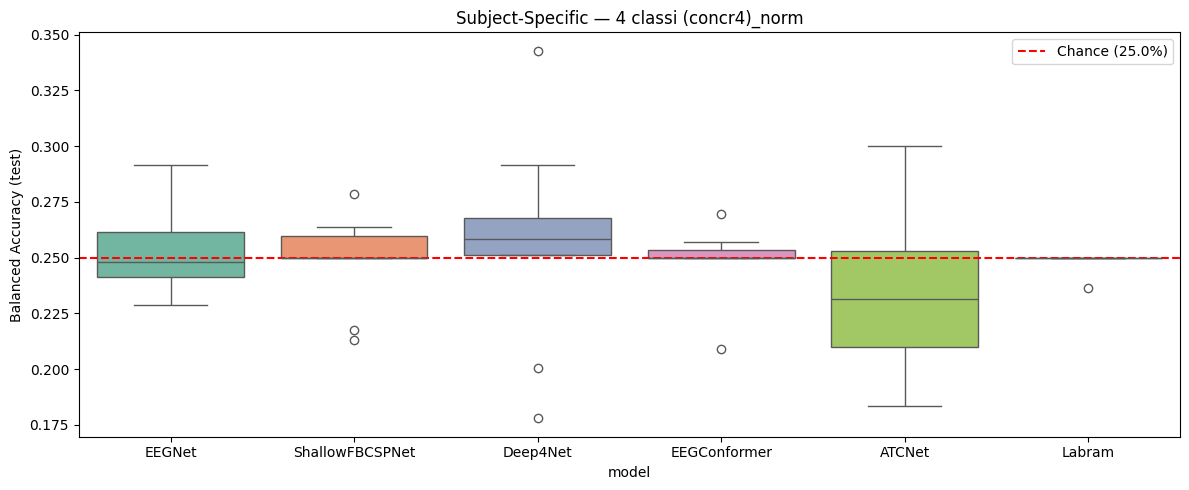

Salvato: figures/eeg06_ss_4_norm_boxplot.png


In [10]:
# ── Boxplot distribuzione per soggetto ──────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=df_ss, x="model", y="test_bacc", ax=ax, palette="Set2")
ax.axhline(chance_level, color="red", linestyle="--", label=f"Chance ({chance_level:.1%})")
ax.set_title(f"Subject-Specific — {N_CLASSES} classi ({CLUSTER_SCHEME}){NORM_TAG}")
ax.set_ylabel("Balanced Accuracy (test)")
ax.legend()
plt.tight_layout()
plt.savefig(project_root / "figures" / f"eeg06_ss_{N_CLASSES}{NORM_TAG}_boxplot.png", dpi=150)
plt.show()
print(f"Salvato: figures/eeg06_ss_{N_CLASSES}{NORM_TAG}_boxplot.png")

In [ ]:
# ============================================================
# RANKING SOGGETTI — ordinati per best test_bacc
# ============================================================
df_ss = pd.read_csv(RESULTS_CSV) if RESULTS_CSV.exists() else pd.DataFrame(all_results)

if df_ss.empty:
    print("Nessun risultato. Esegui prima cell-10.")
else:
    # Per ogni soggetto: media e max tra tutti i modelli
    subj_stats = df_ss.groupby("subject").agg(
        mean_test_bacc=("test_bacc", "mean"),
        max_test_bacc =("test_bacc", "max"),
        best_model    =("model",     lambda x: x.iloc[df_ss.loc[x.index, "test_bacc"].argmax()]),
        n_models      =("model",     "count"),
    ).sort_values("mean_test_bacc", ascending=False).reset_index()

    print(f"{'═'*60}")
    print(f"RANKING SOGGETTI — {_scheme} | Chance={chance_level:.1%}")
    print(f"{'═'*60}")
    print(f"{'Rank':<5} {'Sogg':<6} {'Mean bAcc':>9} {'Max bAcc':>9} {'Best model':<18} {'N'}")
    print(f"{'-'*60}")
    for rank, row in enumerate(subj_stats.itertuples(), 1):
        marker = " ← TOP" if rank <= 3 else (" ← BOTTOM" if rank > len(subj_stats) - 3 else "")
        print(f"  {rank:<4} {str(row.subject):<6} "
              f"{row.mean_test_bacc:>9.4f} {row.max_test_bacc:>9.4f} "
              f"{str(row.best_model):<18} {row.n_models}{marker}")
    print(f"{'═'*60}")
    print(f"Chance level : {chance_level:.4f}")
    print(f"Media globale: {subj_stats['mean_test_bacc'].mean():.4f}")
    print(f"Sogg > chance: {(subj_stats['mean_test_bacc'] > chance_level).sum()} / {len(subj_stats)}")

    # ── Bar chart soggetti ordinati ────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(max(12, len(subj_stats)*0.35), 5))
    colors = ["#2196F3" if v > chance_level else "#F44336"
              for v in subj_stats["mean_test_bacc"]]
    ax.bar(range(len(subj_stats)), subj_stats["mean_test_bacc"],
           color=colors, alpha=0.85)
    ax.axhline(chance_level, color="black", ls="--", lw=1.5,
               label=f"Chance ({chance_level:.1%})")
    ax.set_xticks(range(len(subj_stats)))
    ax.set_xticklabels(subj_stats["subject"].tolist(), rotation=90, fontsize=7)
    ax.set_ylabel("Mean Balanced Accuracy (test)")
    ax.set_title(f"Soggetti ordinati per mean bAcc — {_scheme}\n"
                 f"🔵 > chance  🔴 ≤ chance")
    ax.legend()
    plt.tight_layout()
    _fig_path = project_root / "figures" / f"eeg06_subject_ranking_{_scheme}{NORM_TAG}.png"
    fig.savefig(_fig_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figura: {_fig_path}")